# Laboratorio 3 — Detección de Anomalías con Machine Learning
**Evaluación Práctica Final — Seguridad Informática (Unidad IV)**

| | |
|---|---|
| **Autor** | Jhoel AQ |
| **Curso** | Seguridad Informática — Ciclo IX |
| **Modelo** | Isolation Forest (aprendizaje no supervisado) |
| **Dataset** | `lab3/network_traffic.csv` (10 000 conexiones de red, 30 días) |

Objetivo: entrenar un modelo capaz de detectar tráfico de red anómalo
(posibles exfiltraciones, escaneos o flooding) **sin usar la columna `label`**,
que solo se emplea para validar las métricas.

## Tarea 3.1 — Exploración y preprocesamiento

In [1]:
# --- Librerías ---
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.preprocessing import StandardScaler

# Módulo compartido con predecir.py (mismo feature engineering)
from preprocesamiento import construir_features, COLUMNAS_FEATURES

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# --- Carga del dataset (ruta relativa lab3/network_traffic.csv) ---
CSV = Path("lab3/network_traffic.csv")
if not CSV.exists():
    CSV = Path("network_traffic.csv")     # si el notebook se ejecuta dentro de lab3/
BASE_DIR = CSV.resolve().parent

df = pd.read_csv(CSV)
print(f"Registros: {len(df)}  |  Columnas: {df.shape[1]}")
df.head()

Registros: 10000  |  Columnas: 10


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
0,2024-05-26 04:28:31,10.0.2.118,201.250.32.133,21,TCP,15310,45067,42.01,16,normal
1,2024-05-11 01:38:15,10.0.1.189,193.199.92.89,21,UDP,3692990,68116,55.35,2823,normal
2,2024-05-17 21:00:41,10.0.3.254,202.222.194.7,443,ICMP,23007,950555,6.64,18,normal
3,2024-05-09 18:30:38,10.0.1.254,152.183.142.33,25,TCP,467423,56148,3.12,656,normal
4,2024-05-27 17:50:29,10.0.3.87,64.39.138.32,3306,UDP,15355,18895,16.82,23,normal


In [3]:
# --- Estadísticas descriptivas ---
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,10000,9985,2024-05-11 02:01:51,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_ip,10000,34,10.0.1.180,719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_ip,10000,277,10.0.3.174,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_port,10000.0,NaN,NaN,NaN,5272.9637,7348.395782,21.0,53.0,3389.0,8080.0,65460.0
protocol,10000,3,TCP,6984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bytes_sent,10000.0,NaN,NaN,NaN,28152889.7204,311567107.913308,15.0,5544.0,22339.0,94781.75,4987050489.0
bytes_recv,10000.0,NaN,NaN,NaN,412435.9726,1964278.161379,0.0,13288.0,55290.5,221325.75,81557831.0
duration_sec,10000.0,NaN,NaN,NaN,447.154662,4530.488171,0.0,8.5075,21.435,44.145,83028.15
packets,10000.0,NaN,NaN,NaN,16055.0107,167285.87431,1.0,5.0,24.0,110.0,2939448.0
label,10000,2,normal,9500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# --- Tipos de datos y memoria ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     10000 non-null  object 
 1   src_ip        10000 non-null  object 
 2   dst_ip        10000 non-null  object 
 3   dst_port      10000 non-null  int64  
 4   protocol      10000 non-null  object 
 5   bytes_sent    10000 non-null  int64  
 6   bytes_recv    10000 non-null  int64  
 7   duration_sec  10000 non-null  float64
 8   packets       10000 non-null  int64  
 9   label         10000 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 781.4+ KB


In [5]:
# --- Distribución por protocolo y por etiqueta (solo referencia) ---
print("Protocolo:\n", df["protocol"].value_counts(), "\n")
print("Etiqueta (validación):\n", df["label"].value_counts())

Protocolo:
 protocol
TCP     6984
UDP     2561
ICMP     455
Name: count, dtype: int64 

Etiqueta (validación):
 label
normal     9500
anomaly     500
Name: count, dtype: int64


In [6]:
# --- 1) Valores NULOS ---
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)
print(f"\nTotal de nulos en el dataset: {int(nulos.sum())}")
# Nota: aunque aquí no haya nulos, construir_features() imputa por mediana
# como red de seguridad para datos nuevos en producción.

Valores nulos por columna:
timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64

Total de nulos en el dataset: 0


### Distribución de `bytes_sent` y `duration_sec`
Ambas variables tienen una **cola muy pesada** (unos pocos registros con valores
gigantes). Se muestran en escala original y con `log1p` para evidenciar el efecto
del tratamiento de atípicos.

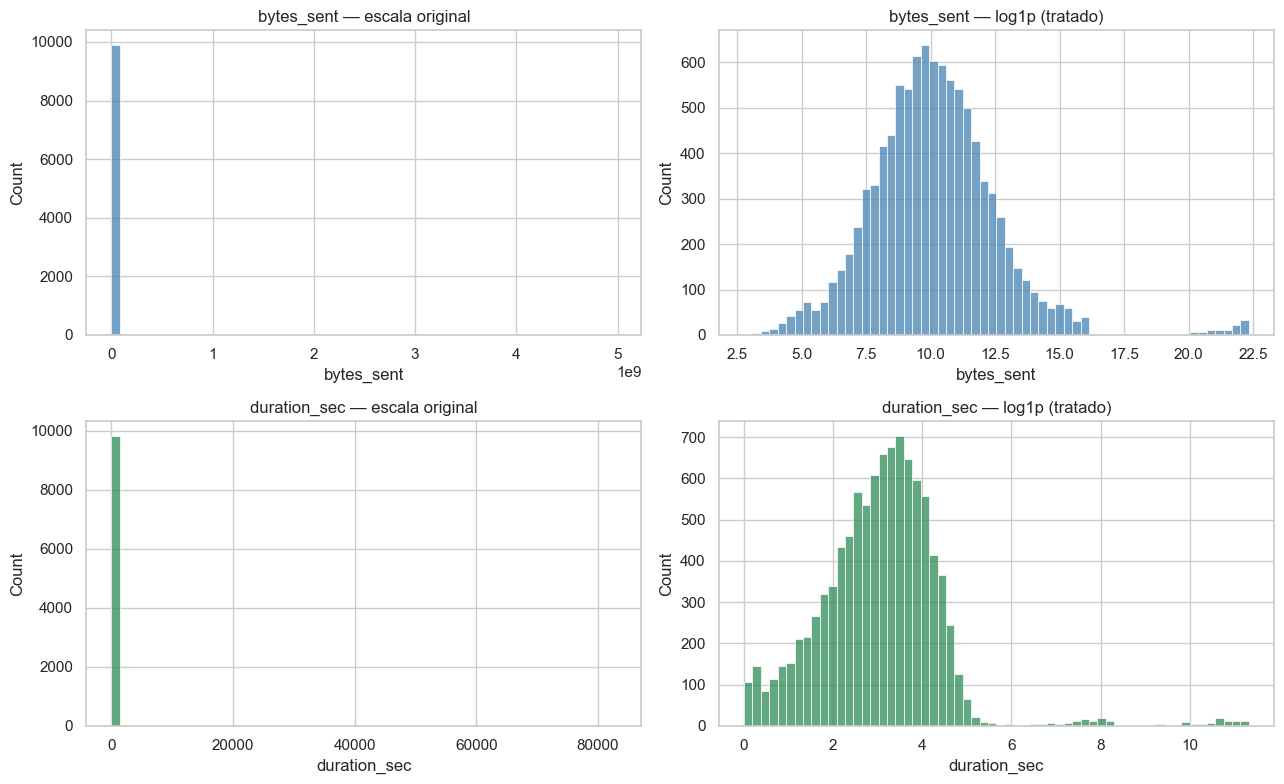

In [7]:
# --- 2) Histogramas ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(df["bytes_sent"], bins=60, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("bytes_sent — escala original")
sns.histplot(np.log1p(df["bytes_sent"]), bins=60, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("bytes_sent — log1p (tratado)")
sns.histplot(df["duration_sec"], bins=60, ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("duration_sec — escala original")
sns.histplot(np.log1p(df["duration_sec"]), bins=60, ax=axes[1, 1], color="seagreen")
axes[1, 1].set_title("duration_sec — log1p (tratado)")
plt.tight_layout(); plt.show()

In [8]:
# --- 3) Atípicos extremos (regla del IQR, Q3 + 3·IQR) ---
for col in ["bytes_sent", "bytes_recv", "duration_sec", "packets"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_sup = q3 + 3 * iqr
    n_out = int((df[col] > lim_sup).sum())
    print(f"{col:<14} Q3+3·IQR = {lim_sup:>14.1f}   atípicos extremos = {n_out}")
print("\nTratamiento aplicado: log1p (comprime la cola SIN borrar las anomalías,")
print("que son precisamente los registros que el modelo debe encontrar).")

bytes_sent     Q3+3·IQR =       362495.0   atípicos extremos = 1053
bytes_recv     Q3+3·IQR =       845439.0   atípicos extremos = 913
duration_sec   Q3+3·IQR =          151.1   atípicos extremos = 254
packets        Q3+3·IQR =          425.0   atípicos extremos = 1099

Tratamiento aplicado: log1p (comprime la cola SIN borrar las anomalías,
que son precisamente los registros que el modelo debe encontrar).


### Feature engineering — variables derivadas
Se crean 5 variables nuevas que capturan el *comportamiento* de la conexión
(no solo su volumen):

| Variable | Fórmula | Qué detecta |
|---|---|---|
| `bytes_totales` | `bytes_sent + bytes_recv` | volumen total de la conexión |
| `ratio_bytes` | `bytes_sent / (bytes_recv+1)` | **exfiltración** (sube mucho más de lo que baja) |
| `bytes_por_segundo` | `bytes_totales / duration` | transferencias muy rápidas / masivas |
| `paquetes_por_segundo` | `packets / duration` | **flooding / escaneo** |
| `bytes_por_paquete` | `bytes_totales / (packets+1)` | tamaño de paquete atípico |

Además se codifica el protocolo con one-hot (`proto_TCP`, `proto_UDP`, `proto_ICMP`).

In [9]:
# --- 4) Construcción de features (módulo compartido) ---
X, medianas = construir_features(df)
nuevas = ["bytes_totales", "ratio_bytes", "bytes_por_segundo",
          "paquetes_por_segundo", "bytes_por_paquete"]
print("Features finales:", list(X.columns))
print("\nResumen de las variables derivadas (ya con log1p):")
X[nuevas].describe().T

Features finales: ['dst_port', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'bytes_totales', 'ratio_bytes', 'bytes_por_segundo', 'paquetes_por_segundo', 'bytes_por_paquete', 'proto_TCP', 'proto_UDP', 'proto_ICMP']

Resumen de las variables derivadas (ya con log1p):


,count,mean,std,min,25%,50%,75%,max
bytes_totales,10000.0,11.922626,2.073975,3.713572,10.745798,11.852639,12.999339,22.330114
ratio_bytes,10000.0,1.140497,1.925707,0.000011,0.061445,0.364225,1.394077,16.029388
bytes_por_segundo,10000.0,9.039223,2.317115,0.014817,7.593875,8.954514,10.436805,27.376014
paquetes_por_segundo,10000.0,1.488636,1.701773,0.003926,0.242786,0.871362,2.145030,17.111347
bytes_por_paquete,10000.0,8.391626,1.971227,0.022534,7.198687,8.015345,9.492332,16.065595


In [10]:
# --- 5) Normalización con StandardScaler ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X),
                        columns=COLUMNAS_FEATURES, index=X.index)
print("Media ≈ 0 y desviación ≈ 1 tras escalar:")
X_scaled.describe().loc[["mean", "std"]].T.round(3)

Media ≈ 0 y desviación ≈ 1 tras escalar:


,mean,std
dst_port,-0.0,1.0
bytes_sent,0.0,1.0
bytes_recv,0.0,1.0
duration_sec,0.0,1.0
packets,-0.0,1.0
bytes_totales,0.0,1.0
ratio_bytes,0.0,1.0
bytes_por_segundo,0.0,1.0
paquetes_por_segundo,0.0,1.0
bytes_por_paquete,0.0,1.0


## Tarea 3.2 — Entrenamiento del modelo

In [11]:
# --- Entrenamiento del Isolation Forest (SIN la columna label) ---
y_true = (df["label"] == "anomaly").astype(int)   # 1 = anomalía, 0 = normal

iso = IsolationForest(contamination=0.05, n_estimators=100,
                      random_state=RANDOM_STATE)
iso.fit(X_scaled)

pred = iso.predict(X_scaled)            # -1 = anomalía, 1 = normal
y_pred = (pred == -1).astype(int)
print("Modelo entrenado con", iso.n_estimators, "árboles.")
print(f"Anomalías detectadas: {int(y_pred.sum())} de {len(df)} registros "
      f"({100*y_pred.mean():.1f} %)")

Modelo entrenado con 100 árboles.
Anomalías detectadas: 500 de 10000 registros (5.0 %)


In [12]:
# --- Métricas de evaluación (clase positiva = anomaly) ---
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["normal", "anomaly"]))

Precision : 0.8200
Recall    : 0.8200
F1-Score  : 0.8200

              precision    recall  f1-score   support

      normal       0.99      0.99      0.99      9500
     anomaly       0.82      0.82      0.82       500

    accuracy                           0.98     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.98      0.98      0.98     10000



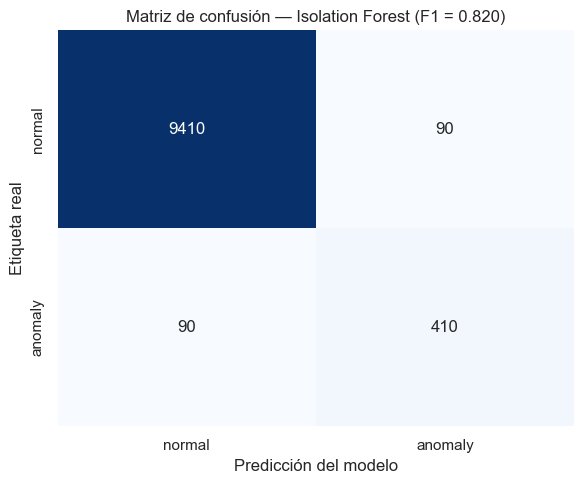

In [13]:
# --- Matriz de confusión (seaborn) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["normal", "anomaly"],
            yticklabels=["normal", "anomaly"])
plt.title(f"Matriz de confusión — Isolation Forest (F1 = {f1:.3f})")
plt.ylabel("Etiqueta real"); plt.xlabel("Predicción del modelo")
plt.tight_layout(); plt.show()

## Tarea 3.3 — Interpretación y umbral dinámico

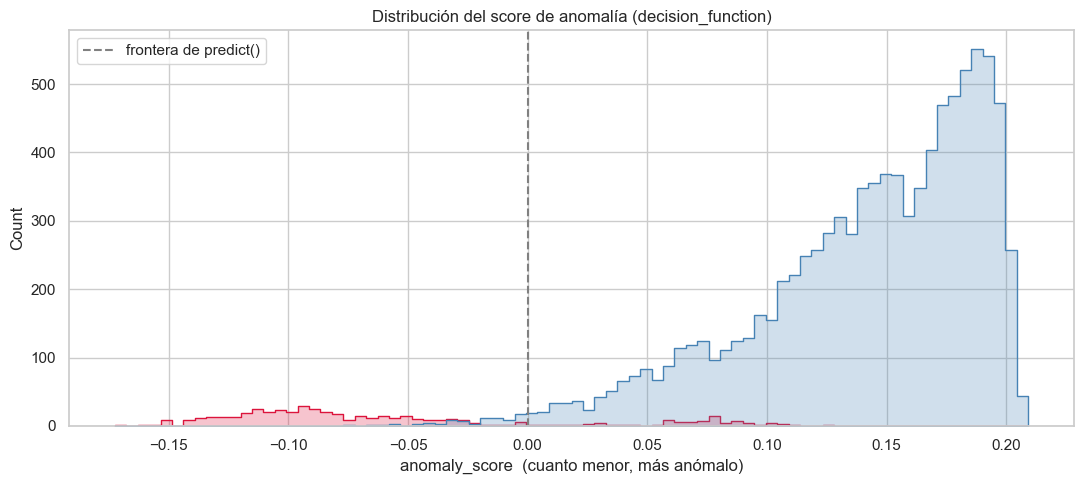

In [14]:
# --- Score de anomalía para TODOS los registros ---
scores = iso.decision_function(X_scaled)
df_scores = df.copy()
df_scores["anomaly_score"] = scores

plt.figure(figsize=(11, 5))
sns.histplot(data=df_scores, x="anomaly_score", hue="label", bins=80,
             palette={"normal": "steelblue", "anomaly": "crimson"},
             element="step", stat="count")
plt.axvline(0, color="gray", ls="--", label="frontera de predict()")
plt.title("Distribución del score de anomalía (decision_function)")
plt.xlabel("anomaly_score  (cuanto menor, más anómalo)")
plt.legend(); plt.tight_layout(); plt.show()

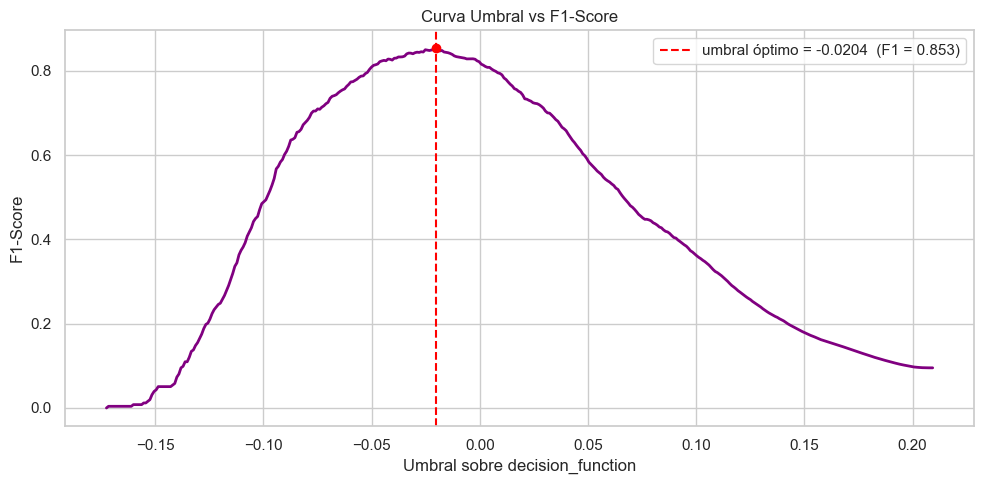

Umbral óptimo = -0.0204  ->  F1 = 0.8535  (vs F1 = 0.8200 con la frontera por defecto)


In [15]:
# --- Umbral óptimo que MAXIMIZA el F1-Score ---
umbrales = np.linspace(scores.min(), scores.max(), 400)
f1s = [f1_score(y_true, (scores < t).astype(int)) for t in umbrales]
idx = int(np.argmax(f1s))
umbral_opt, f1_opt = float(umbrales[idx]), float(f1s[idx])

plt.figure(figsize=(10, 5))
plt.plot(umbrales, f1s, color="purple", linewidth=2)
plt.axvline(umbral_opt, color="red", ls="--",
            label=f"umbral óptimo = {umbral_opt:.4f}  (F1 = {f1_opt:.3f})")
plt.scatter([umbral_opt], [f1_opt], color="red", zorder=5)
plt.title("Curva Umbral vs F1-Score")
plt.xlabel("Umbral sobre decision_function"); plt.ylabel("F1-Score")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Umbral óptimo = {umbral_opt:.4f}  ->  F1 = {f1_opt:.4f}  "
      f"(vs F1 = {f1:.4f} con la frontera por defecto)")

In [16]:
# --- Top 10 registros MÁS anómalos del dataset ---
cols_orden = ["timestamp", "src_ip", "dst_ip", "dst_port", "protocol",
              "bytes_sent", "bytes_recv", "duration_sec", "packets",
              "label", "anomaly_score"]
top10 = df_scores.sort_values("anomaly_score").head(10)[cols_orden]
top10.reset_index(drop=True)

,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label,anomaly_score
0,2024-05-07 02:28:18,10.0.3.75,143.109.217.176,8080,ICMP,4006296316,12306,3330.27,344980,anomaly,-0.172490
1,2024-05-28 05:02:43,10.0.0.218,185.220.101.45,53,ICMP,1828360491,42113,3434.68,1897632,anomaly,-0.160102
2,2024-05-18 01:17:02,10.0.3.25,185.220.101.45,8080,UDP,3381243245,9692,3380.80,1125058,anomaly,-0.155719
3,2024-05-13 04:18:10,10.0.1.180,185.220.101.45,443,ICMP,1444990529,21400,990.63,2260655,anomaly,-0.153682
4,2024-05-17 04:39:05,10.0.1.254,38.168.189.92,80,UDP,4696305972,21229,383.65,1693674,anomaly,-0.153091
5,2024-05-20 02:33:10,10.0.0.93,162.247.74.201,443,UDP,2564520566,13741,2067.59,2063474,anomaly,-0.152213
6,2024-05-22 04:24:05,10.0.1.83,134.254.60.66,53,ICMP,8746305,11,7.41,76098,anomaly,-0.151838
7,2024-05-24 05:37:17,10.0.0.237,179.227.63.96,53,UDP,4112441880,36145,1020.62,1612806,anomaly,-0.151623
8,2024-05-06 03:31:59,10.0.3.187,45.33.32.156,8080,UDP,1001361799,6715,2060.72,2871773,anomaly,-0.150646
9,2024-05-25 03:13:49,10.0.0.218,45.33.32.156,443,UDP,3628053485,19496,1451.84,2563437,anomaly,-0.150646


### ¿Por qué estos registros representan una amenaza real?

Los 10 registros con menor `anomaly_score` comparten patrones que en un SOC se
consideran indicadores de compromiso:

1. **Exfiltración de datos** — `ratio_bytes` muy alto: la conexión **envía**
   muchísimos más bytes de los que recibe, con `bytes_por_segundo` elevado.
   Es el patrón clásico de un host interno subiendo datos a un servidor externo.
2. **Flooding / DoS o escaneo** — `paquetes_por_segundo` extremo con duraciones
   muy cortas: miles de paquetes pequeños en segundos.
3. **Combinaciones puerto/protocolo atípicas** — p. ej. grandes volúmenes sobre
   `ICMP` (que normalmente transporta poco) o tráfico masivo a puertos no
   estándar, típico de túneles encubiertos (covert channels).
4. **Tamaño de paquete anómalo** (`bytes_por_paquete`) — fuera del rango normal
   del protocolo, señal de payloads manipulados.

La mayoría de estos Top 10 están etiquetados como `anomaly`, lo que confirma que
el modelo **prioriza correctamente** las conexiones más peligrosas para que un
analista las revise primero.

## Tarea 3.4 — Exportación del modelo

In [17]:
# --- Serialización con joblib ---
# Se guarda un "bundle" con todo lo necesario para reproducir la inferencia:
# el modelo, el scaler, el orden de features, las medianas de imputación y el
# umbral óptimo. Así predecir.py reconstruye exactamente el mismo pipeline.
MODELO = BASE_DIR / "modelo_anomalias.pkl"
bundle = {
    "model": iso,
    "scaler": scaler,
    "features": COLUMNAS_FEATURES,
    "medianas": medianas,
    "umbral": umbral_opt,
    "metrica_f1": f1_opt,
}
joblib.dump(bundle, MODELO)
print(f"Modelo serializado en: {MODELO.name}  ({MODELO.stat().st_size/1024:.1f} KB)")

Modelo serializado en: modelo_anomalias.pkl  (1041.4 KB)


In [18]:
# --- CSV de prueba para predecir.py (tráfico 'nuevo', sin columna label) ---
muestra = pd.concat([
    df[df.label == "anomaly"].sample(15, random_state=RANDOM_STATE),
    df[df.label == "normal"].sample(35, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE).drop(columns=["label"])
NUEVO = BASE_DIR / "nuevo_trafico.csv"
muestra.to_csv(NUEVO, index=False)
print(f"Archivo de prueba generado: {NUEVO.name}  ({len(muestra)} registros)")

Archivo de prueba generado: nuevo_trafico.csv  (50 registros)


### Uso del script de inferencia

```bash
python predecir.py nuevo_trafico.csv
```

`predecir.py` carga `modelo_anomalias.pkl`, aplica el mismo feature engineering
(`preprocesamiento.construir_features`) y el scaler, y lista por consola los
registros clasificados como **anomalía** junto con su `anomaly_score`.

---
**Fin del Laboratorio 3.**